## Пример обучения PCA

### Предобработка данных

In [1]:
import pandas as pd


df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18t4_sleep.csv')

print(f'Размер датасета: {df.shape}')


print('\nПропуски в колонках:')
print(df.isnull().sum())

print('\nМинимальные, средние и максимальные значения признаков:')
print(df.describe().T[['min', 'mean', 'max']])

Размер датасета: (5000, 12)

Пропуски в колонках:
age                 0
marital-status      0
gender              0
bmi                 0
snoring-rate        0
respiration-rate    0
body-temperature    0
limb-movement       0
blood-oxygen        0
eye-movement        0
sleeping-hours      0
heart-rate          0
dtype: int64

Минимальные, средние и максимальные значения признаков:
                    min       mean     max
age                0.08  42.789176   82.00
marital-status     0.00   0.488800    1.00
gender             0.00   0.417800    1.00
bmi               11.30  27.503898   97.60
snoring-rate       0.00  20.566800   99.00
respiration-rate  10.00  16.324800   25.00
body-temperature  79.03  91.920722   99.30
limb-movement      0.00  11.669907   25.00
blood-oxygen      75.00  91.288154   99.00
eye-movement      20.00  28.657912  104.96
sleeping-hours     0.00   4.090151    9.00
heart-rate        50.00  65.547672   88.00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=627)

transformer = Pipeline([
    ('scaler', StandardScaler())
])

train_scaled_values = transformer.fit_transform(train_df)
train_scaled = pd.DataFrame(train_scaled_values, columns=train_df.columns, index=train_df.index)

print('\nСтатистика преобразованных данных:')
print(train_scaled.describe().T[['min', 'mean', 'max']])


Статистика преобразованных данных:
                       min          mean       max
age              -1.896156  3.552714e-18  1.753956
marital-status   -0.980686 -7.815970e-17  1.019694
gender           -0.847039 -9.947598e-17  1.180583
bmi              -2.111744  2.273737e-16  9.192065
snoring-rate     -1.907947  1.751932e-16  7.256974
respiration-rate -1.937736  2.131628e-16  2.634553
body-temperature -2.883854 -2.131628e-17  1.644619
limb-movement    -2.683860  3.415046e-16  3.066319
blood-oxygen     -3.709030  7.682743e-17  1.760321
eye-movement     -0.477721 -1.776357e-17  4.284119
sleeping-hours   -1.313835  1.176836e-16  1.571866
heart-rate       -1.543742 -2.771117e-16  2.244557


### Обучение PCA

In [3]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_df, test_df = train_test_split(df, test_size=0.2, random_state=627)

transformer = Pipeline([
    ('scaler', StandardScaler())
])

train_scaled_values = transformer.fit_transform(train_df)
test_scaled_values = transformer.transform(test_df)


# Создаём объект класса PCA
pca = PCA(n_components=2)  # Оставим только 2 главные компоненты

# Обучаем PCA на данных
pca.fit(train_scaled_values)

# Преобразуем данные
X_train_pca_values = pca.transform(train_scaled_values)
X_test_pca_values = pca.transform(test_scaled_values)


# Дадим названия новым признакам
n_components = X_train_pca_values.shape[1]
columns = [f'PC{i+1}' for i in range(n_components)]

# Преобразуем в датасет
X_train_pca = pd.DataFrame(X_train_pca_values, columns=columns)

print(f'Старый размер датасета: {train_df.shape}\n')
print(f'Новый размер датасета: {X_train_pca.shape}\n')
print(X_train_pca.head())

Старый размер датасета: (4000, 12)

Новый размер датасета: (4000, 2)

        PC1       PC2
0 -2.853316 -0.660123
1 -0.755023 -0.973453
2 -2.855218 -0.638190
3 -2.245942 -0.068194
4  3.106593 -0.631611


In [4]:
# Создаём пайплайн: сначала масштабируем, потом выделяем главные компоненты
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('pca', PCA(n_components=2))   
])

pipeline.fit(train_df)

# Преобразуем данные
X_train_pca_values = pipeline.transform(train_df)
X_test_pca_values = pipeline.transform(test_df)

n_components = X_train_pca_values.shape[1]
columns = [f'PC{i+1}' for i in range(n_components)]
X_train_pca = pd.DataFrame(X_train_pca_values, columns=columns)

print(f'Новый размер датасета после пайплайна: {X_train_pca.shape}\n')
print(X_train_pca.head())

Новый размер датасета после пайплайна: (4000, 2)

        PC1       PC2
0 -2.853316 -0.660123
1 -0.755023 -0.973453
2 -2.855218 -0.638190
3 -2.245942 -0.068194
4  3.106593 -0.631611


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

impute_cols = ['marital-status', 'gender'] # Признаки с пропусками
other_cols = [col for col in df.columns if col not in impute_cols] 

preprocessor = ColumnTransformer(
    transformers=[
        ('impute', SimpleImputer(strategy='constant', fill_value=0.5), impute_cols),
        ('pass', 'passthrough', other_cols) # Остальные колонки без изменений
    ]
)
pipeline = Pipeline(
    [
        ('preproc', preprocessor),
        ('scaler', StandardScaler()),  
        ('pca', PCA(n_components=5, random_state=627))
    ]
) # Допишите пайплайн

# Обучите пайплайн
pipeline.fit(train_df)

X_test_pca_values = pipeline.transform(test_df) # Преобразуйте тестовые данные

n_components = X_test_pca_values.shape[1]
columns = [f'PC{i+1}' for i in range(n_components)]
X_test_pca = pd.DataFrame(X_test_pca_values, columns=columns)

print(f'Новый размер датасета после пайплайна: {X_test_pca.shape}\n')
print(X_test_pca.head())

ValueError: The dtype of the filling value (i.e. dtype('float64')) cannot be cast to the input data that is dtype('int64'). Make sure that the dtypes of the input data is of the same kind between fit and transform.

### Анализ доли объясненной дисперсии в данных

In [16]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


transformer = Pipeline([
    ('scaler', StandardScaler())
])
train_scaled_values = transformer.fit_transform(train_df)
test_scaled_values = transformer.transform(test_df)

pca = PCA(n_components=12, random_state=627)
pca.fit(train_scaled_values)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Оформим в виде таблицы
import pandas as pd
table = pd.DataFrame({
    'Количество компонент': range(1, len(cumulative_variance) + 1),
    'Суммарная объяснённая дисперсия': cumulative_variance
})
print(table)

    Количество компонент  Суммарная объяснённая дисперсия
0                      1                         0.298432
1                      2                         0.407308
2                      3                         0.507543
3                      4                         0.593396
4                      5                         0.675553
5                      6                         0.753390
6                      7                         0.825755
7                      8                         0.884326
8                      9                         0.930883
9                     10                         0.969393
10                    11                         0.992007
11                    12                         1.000000


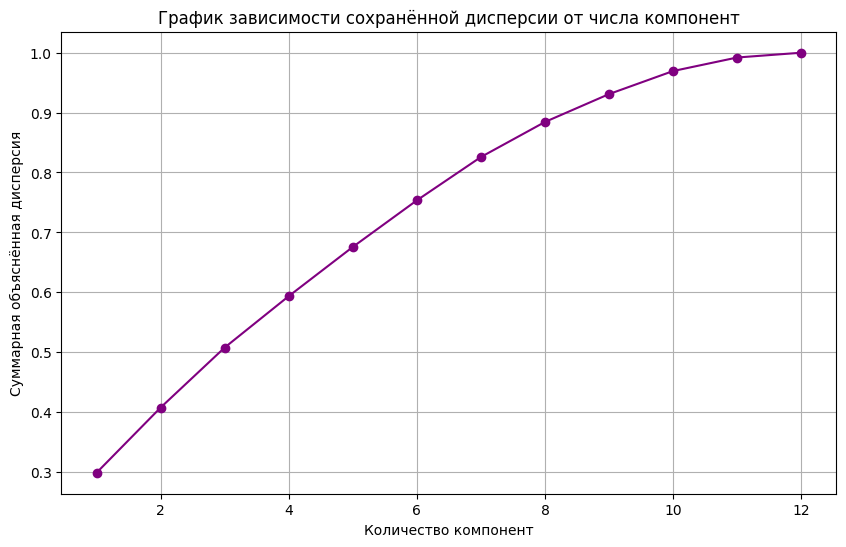

In [17]:
import numpy as np
import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='purple')
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.title('График зависимости сохранённой дисперсии от числа компонент')
plt.grid(True)
plt.show()

## Практика PCA

### Загрузка данных

In [18]:
import pandas as pd

df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18t4_sleep_with_target.csv')

print('Первые строки:')
print(df.head())

print(f'\nРазмер датасета: {df.shape}')

print('\nПропуски в колонках:')
print(df.isnull().sum())

print('\nМинимальные, средние и максимальные значения признаков:')
print(df.describe().T[['min', 'mean', 'max']])

Первые строки:
    age  marital_status  gender     bmi  snoring_rate  respiration_rate  \
0  64.0               0  Female  33.310          15.0              15.0   
1   1.0               1    Male  16.624          18.0              14.0   
2  64.0               1  Female  25.180          11.0              19.0   
3  45.0               0    Male  33.950          22.0              16.0   
4  45.0               1    Male  26.530          41.0              17.0   

   body_temperature  limb_movement  blood_oxygen  eye_movement  \
0         30.021731      29.553005       94.3456          24.0   
1         15.017265      34.004524      100.8000          24.0   
2         22.755203      34.200663      100.0592          25.0   
3         30.569001      30.863233       96.5264          25.0   
4         23.947424      34.382154      103.4616          27.0   

   sleeping_hours  heart_rate  stress_level  
0          2.0000   13.548847      1.000000  
1          6.1776   12.681399      0.999234  

In [20]:
from sklearn.preprocessing import FunctionTransformer

# Функция для преобразования 
# Заменяет строковые значения gender на числа
def gender_to_num(value):
    return np.where(
        value == 'Male', 1,
        np.where(value == 'Female', 0, 0.5)
    ).reshape(-1, 1)

# Создаём трансформер на основе нашей функции
gender_transformer = FunctionTransformer(gender_to_num, validate=False) 

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X, y = df.drop('stress_level', axis=1), df['stress_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=627)

cols_to_scale = [col for col in X.columns if col not in  ['gender']]
preprocessor = ColumnTransformer([
    ('gender', gender_transformer, ['gender']), # Добавьте нужные классы для обработки
    ('num', StandardScaler(), cols_to_scale),
])

pipeline_wo_pca = Pipeline([
    ('preprocessor', preprocessor), # Допишите классы для шагов пайплайна
    ('model', LinearRegression())
])

# Обучите пайплайн pipeline_wo_pca на X_train и y_train
pipeline_wo_pca.fit(X_train, y_train)

y_pred = pipeline_wo_pca.predict(X_test)

# Оценка качества
res_r2 = r2_score(y_test, y_pred)
res_mae = mean_absolute_error(y_test, y_pred)
print(f"Качество на тестовой выборке: r2 = {res_r2:.4f}, MAE = {res_mae:.4f}")

Качество на тестовой выборке: r2 = 0.1046, MAE = 0.2593


In [24]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Функция для обучения и оценки качества пайплайна
def evaluate_pipeline(pipeline, X_train, X_test, y_train, y_test):
    
    # Допишите код для обучения переданного пайплайна
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    res_r2 = r2_score(y_test, y_pred)
    res_mae = mean_absolute_error(y_test, y_pred)
    return {'r2': res_r2, 'mae': res_mae}


X, y = df.drop('stress_level', axis=1), df['stress_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=627)

def gender_to_num(value):
	return np.where(
		value == 'Male', 1,
		np.where(value == 'Female', 0, 0.5)
	).reshape(-1, 1)
gender_transformer = FunctionTransformer(gender_to_num, validate=False)

cols_to_scale = [col for col in X.columns if col not in  ['gender']]
preprocessor = ColumnTransformer([
    ('gender', gender_transformer, ['gender']),
    ('num', StandardScaler(), cols_to_scale),
])

pipeline_pca_n2 = Pipeline([
    ('preprocessor', preprocessor), # Допишите классы для шагов пайплайна
    ('pca', PCA(n_components=2, random_state=627)),
    ('model', LinearRegression())
])

res_pca_n2 = evaluate_pipeline(pipeline_pca_n2, X_train, X_test, y_train, y_test) # Передайте пайплайн в функцию
print(f"Качество на тестовой выборке: r2 = {res_pca_n2['r2']:.4f}, MAE = {res_pca_n2['mae']:.4f}")

Качество на тестовой выборке: r2 = 0.0841, MAE = 0.2625


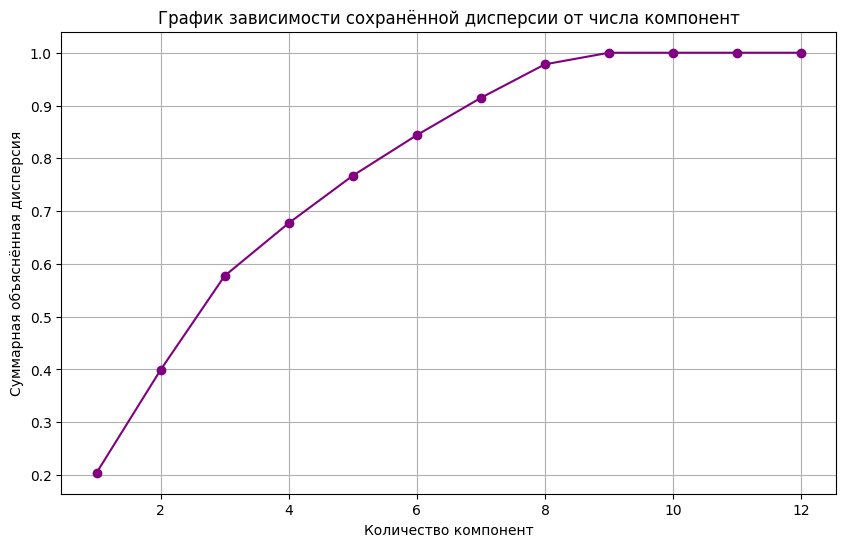

In [25]:
preprocessor = ColumnTransformer([
    ('gender', gender_transformer, ['gender']),
    ('num', StandardScaler(), cols_to_scale),
])

pipeline_pca_n12 = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=12, random_state=627)),
])
pipeline_pca_n12.fit(X_train, y_train)

pca = pipeline_pca_n12['pca'] # Возьмите из пайплайна объект класса PCA 
explained_variance = pca.explained_variance_ratio_# Сохраните в переменную значения атрибута с долей дисперсии
cumulative_variance = np.cumsum(explained_variance) # Посчитайте кумулятивную сумму

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    color='purple'
)
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объяснённая дисперсия')
plt.title('График зависимости сохранённой дисперсии от числа компонент')
plt.grid(True)
plt.show()